<a href="https://colab.research.google.com/github/Anakha10/northstar-analytics/blob/main/NorthStar_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
base_url = "https://raw.githubusercontent.com/Anakha10/northstar-analytics/main/"
customers <- read.csv(paste0(base_url, "customers.csv"))
orders <- read.csv(paste0(base_url, "orders.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))
drivers <- read.csv(paste0(base_url, "drivers.csv"))
vehicles <- read.csv(paste0(base_url, "vehicles.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))
incidents <- read.csv(paste0(base_url, "incidents.csv"))
app_events <- read.csv(paste0(base_url, "app_events.csv"))
cat("All files loaded!\n")

All files loaded!


In [3]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(sqldf)
library(ggplot2)
library(dplyr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [9]:
delivery_summary <- sqldf("
SELECT delivery_status, COUNT(*) AS total
FROM deliveries
GROUP BY delivery_status
")

print(delivery_summary)

  delivery_status total
1         Delayed   202
2          Failed   132
3          OnTime   616


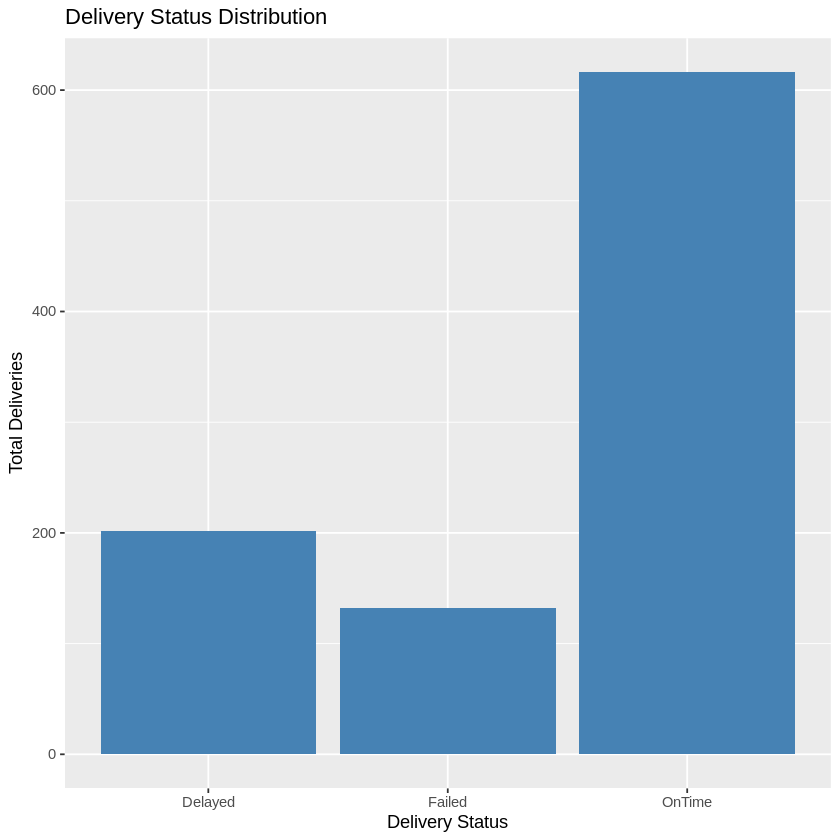

In [10]:
ggplot(delivery_summary, aes(x = delivery_status, y = total)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  ggtitle("Delivery Status Distribution") +
  xlab("Delivery Status") +
  ylab("Total Deliveries")

In [11]:
avg_cost <- sqldf("
SELECT delivery_status, AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY delivery_status
")

print(avg_cost)

  delivery_status avg_cost
1         Delayed 13.13871
2          Failed 13.14795
3          OnTime 12.67805


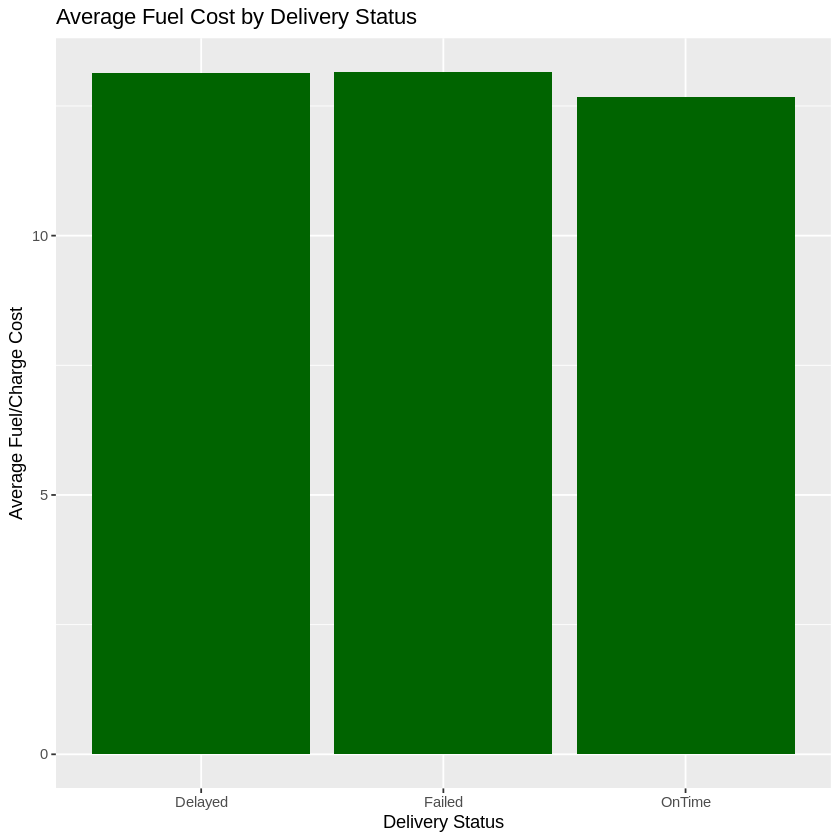

In [12]:
ggplot(avg_cost, aes(x = delivery_status, y = avg_cost)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  ggtitle("Average Fuel Cost by Delivery Status") +
  xlab("Delivery Status") +
  ylab("Average Fuel/Charge Cost")

In [13]:
route_override <- sqldf("
SELECT delivery_status,
AVG(manual_route_override_count) AS avg_override
FROM deliveries
GROUP BY delivery_status
")

print(route_override)

  delivery_status avg_override
1         Delayed    1.0742574
2          Failed    1.0378788
3          OnTime    0.9204545


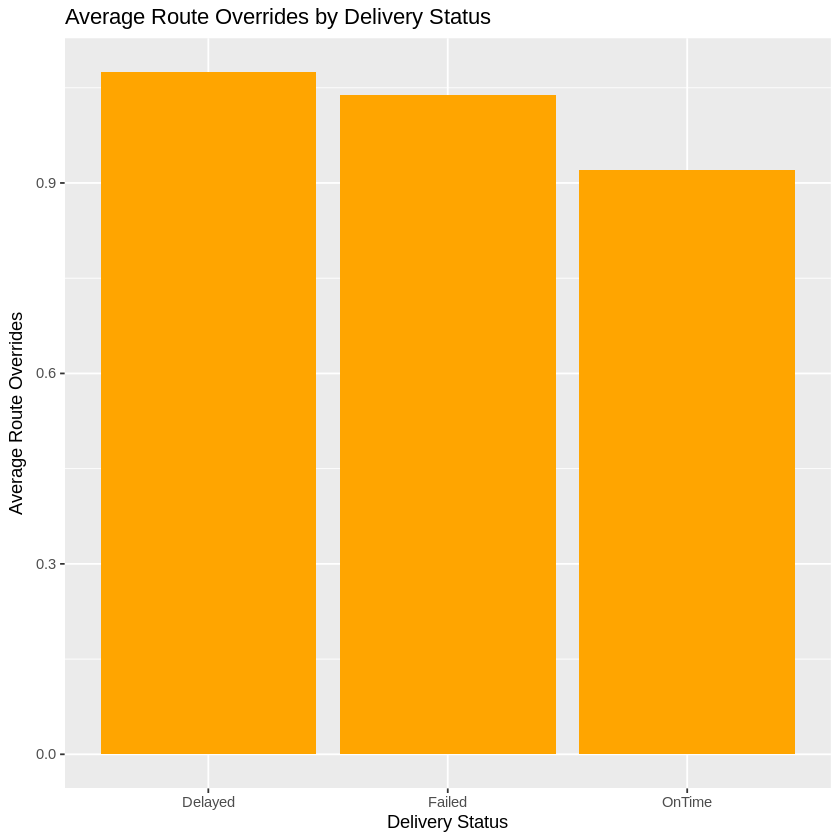

In [14]:
ggplot(route_override, aes(x = delivery_status, y = avg_override)) +
  geom_bar(stat = "identity", fill = "orange") +
  ggtitle("Average Route Overrides by Delivery Status") +
  xlab("Delivery Status") +
  ylab("Average Route Overrides")

In [15]:
driver_analysis <- sqldf("
SELECT d.delivery_status,
AVG(dr.driver_rating) AS avg_driver_rating
FROM deliveries d
JOIN drivers dr
ON d.driver_id = dr.driver_id
GROUP BY d.delivery_status
")

print(driver_analysis)

  delivery_status avg_driver_rating
1         Delayed          4.122723
2          Failed          4.080303
3          OnTime          4.195065


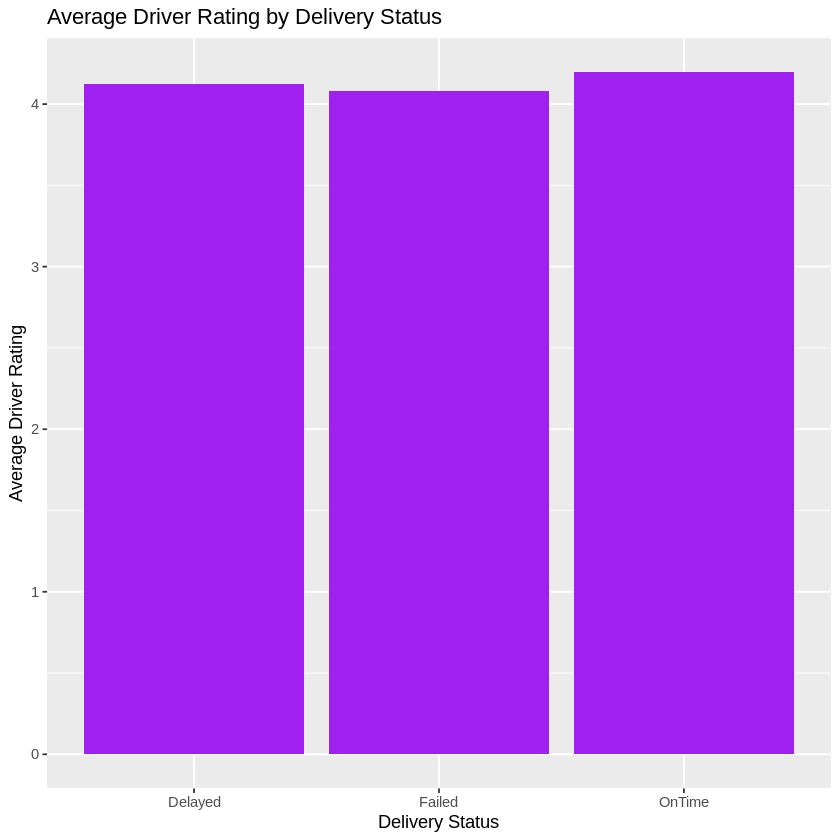

In [16]:
ggplot(driver_analysis, aes(x = delivery_status, y = avg_driver_rating)) +
  geom_bar(stat = "identity", fill = "purple") +
  ggtitle("Average Driver Rating by Delivery Status") +
  xlab("Delivery Status") +
  ylab("Average Driver Rating")

In [17]:
hub_analysis <- sqldf("
SELECT h.zone,
COUNT(*) AS total_deliveries
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.zone
")

print(hub_analysis)

       zone total_deliveries
1   Airport              104
2   Central              243
3      East              119
4     North              136
5 Riverside              115
6     South              106
7      West              127


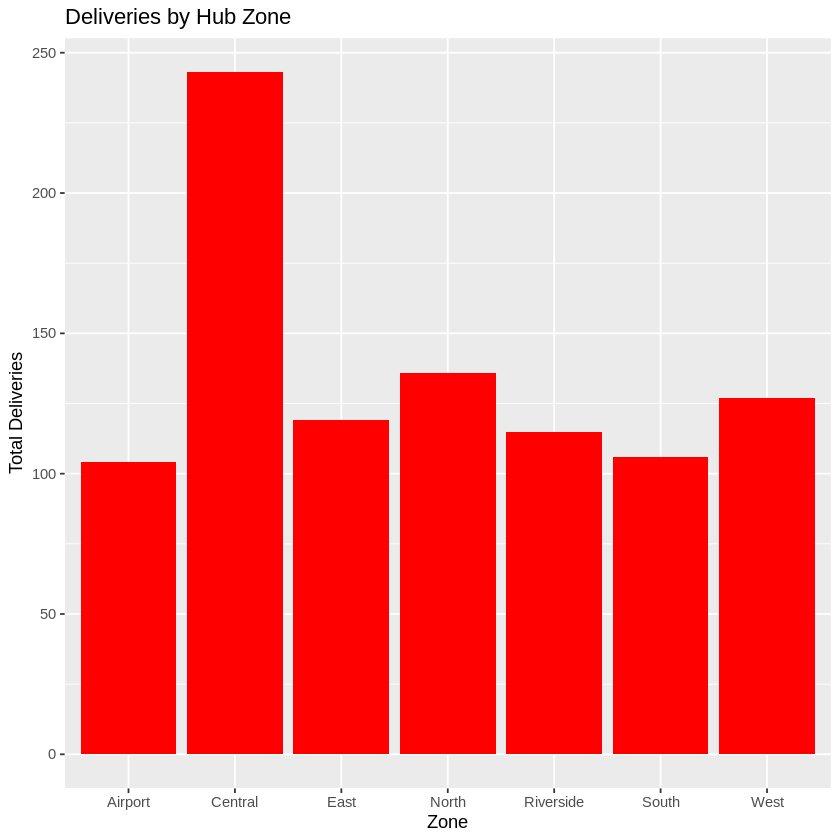

In [18]:
ggplot(hub_analysis, aes(x = zone, y = total_deliveries)) +
  geom_bar(stat = "identity", fill = "red") +
  ggtitle("Deliveries by Hub Zone") +
  xlab("Zone") +
  ylab("Total Deliveries")

In [ ]:
sqldf("
SELECT delivery_id, driver_id, hub_id, delivery_status, fuel_or_charge_cost
FROM deliveries
WHERE delivery_status != 'Completed'
LIMIT 10
")

delivery_id,driver_id,hub_id,delivery_status,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<dbl>
DL00001,D004,H05,Failed,12.05
DL00002,D138,H02,OnTime,13.41
DL00003,D006,H02,OnTime,8.51
DL00004,D116,H02,Delayed,13.62
DL00005,D108,H01,OnTime,9.22
DL00006,D037,H03,Delayed,9.58
DL00007,D151,H07,Delayed,17.70
DL00008,D082,H03,OnTime,11.66
DL00009,D088,H05,OnTime,15.78


In [19]:
avg_cost <- sqldf("
SELECT delivery_status, AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY delivery_status
")

print(avg_cost)

  delivery_status avg_cost
1         Delayed 13.13871
2          Failed 13.14795
3          OnTime 12.67805


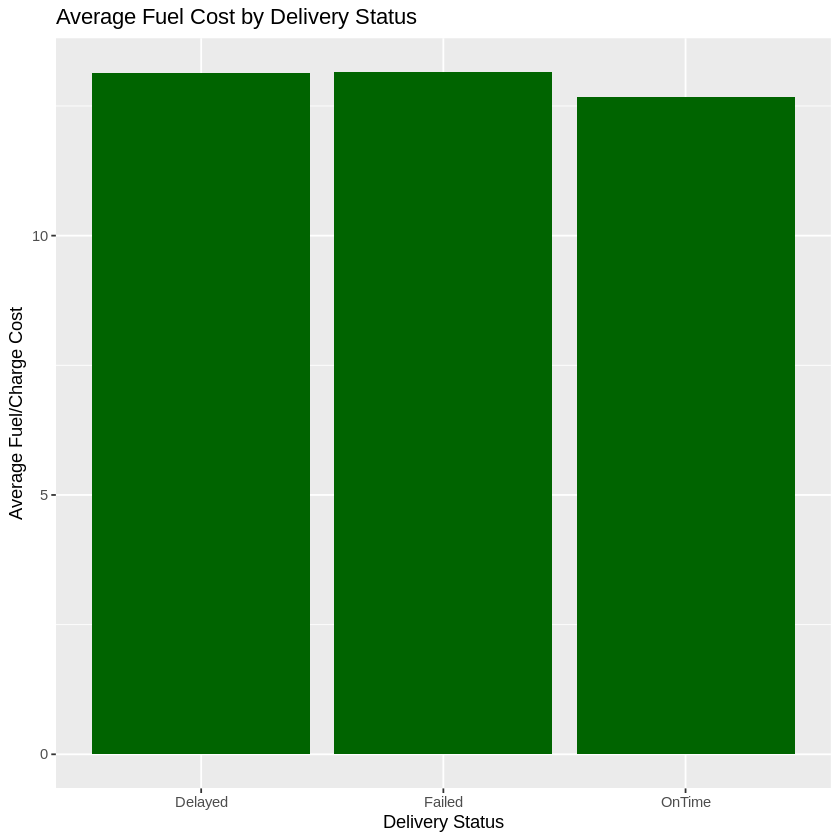

In [20]:
ggplot(avg_cost, aes(x = delivery_status, y = avg_cost)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  ggtitle("Average Fuel Cost by Delivery Status") +
  xlab("Delivery Status") +
  ylab("Average Fuel/Charge Cost")

In [22]:
hub_status <- sqldf("
SELECT h.zone, d.delivery_status, COUNT(*) AS total_deliveries
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.zone, d.delivery_status
ORDER BY h.zone
")

print(hub_status)

        zone delivery_status total_deliveries
1    Airport         Delayed               27
2    Airport          Failed               15
3    Airport          OnTime               62
4    Central         Delayed               47
5    Central          Failed               49
6    Central          OnTime              147
7       East         Delayed               23
8       East          Failed               11
9       East          OnTime               85
10     North         Delayed               26
11     North          Failed               17
12     North          OnTime               93
13 Riverside         Delayed               25
14 Riverside          Failed               14
15 Riverside          OnTime               76
16     South         Delayed               26
17     South          Failed               10
18     South          OnTime               70
19      West         Delayed               28
20      West          Failed               16
21      West          OnTime      

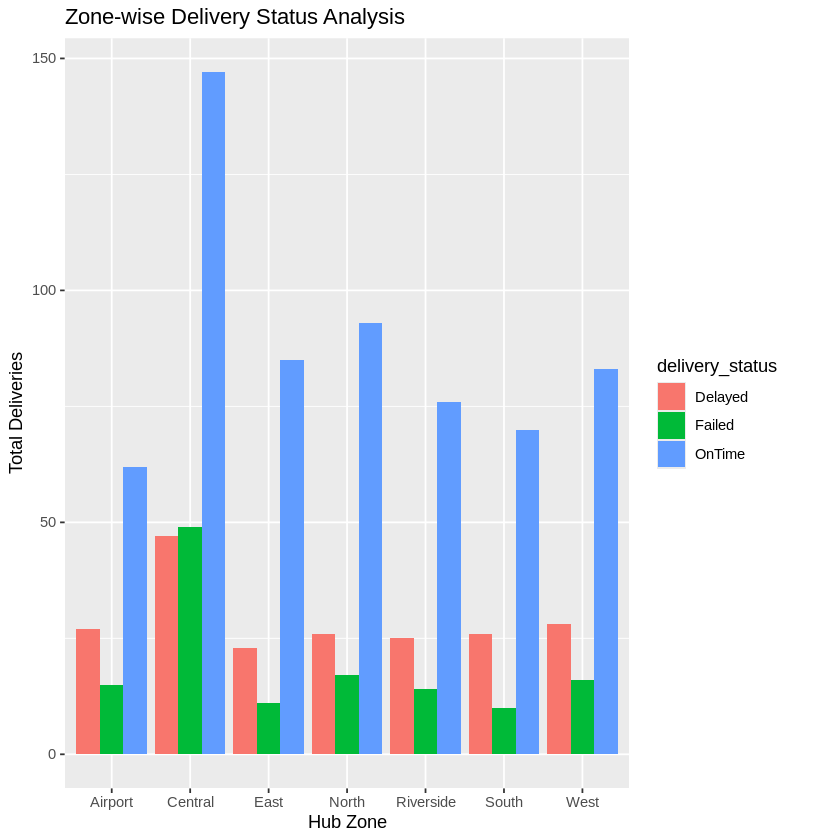

In [23]:
ggplot(hub_status, aes(x = zone, y = total_deliveries, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  ggtitle("Zone-wise Delivery Status Analysis") +
  xlab("Hub Zone") +
  ylab("Total Deliveries")

In [24]:
driver_problem <- sqldf("
SELECT dr.driver_id, dr.driver_rating, COUNT(*) AS total_problem_deliveries
FROM deliveries d
JOIN drivers dr
ON d.driver_id = dr.driver_id
WHERE d.delivery_status IN ('Delayed', 'Failed')
GROUP BY dr.driver_id, dr.driver_rating
ORDER BY total_problem_deliveries DESC
LIMIT 10
")

print(driver_problem)

   driver_id driver_rating total_problem_deliveries
1       D100          4.31                        6
2       D133          3.99                        6
3       D141          3.44                        6
4       D053          3.80                        5
5       D055          5.00                        5
6       D131          4.26                        5
7       D004          4.75                        4
8       D023          4.16                        4
9       D024          3.35                        4
10      D026          3.15                        4


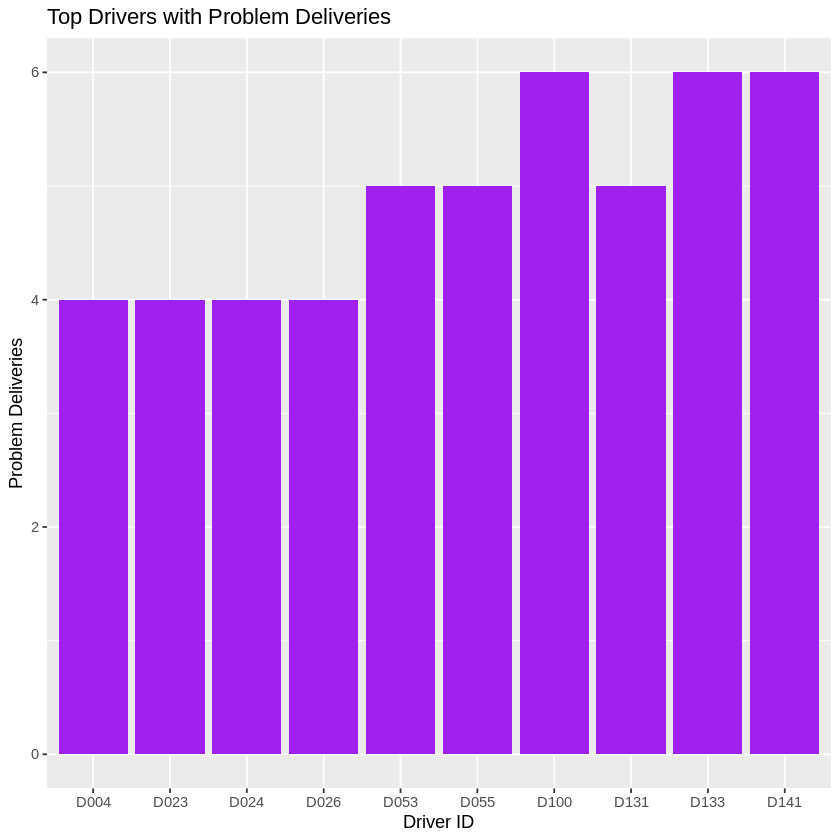

In [25]:
ggplot(driver_problem, aes(x = as.factor(driver_id), y = total_problem_deliveries)) +
  geom_bar(stat = "identity", fill = "purple") +
  ggtitle("Top Drivers with Problem Deliveries") +
  xlab("Driver ID") +
  ylab("Problem Deliveries")

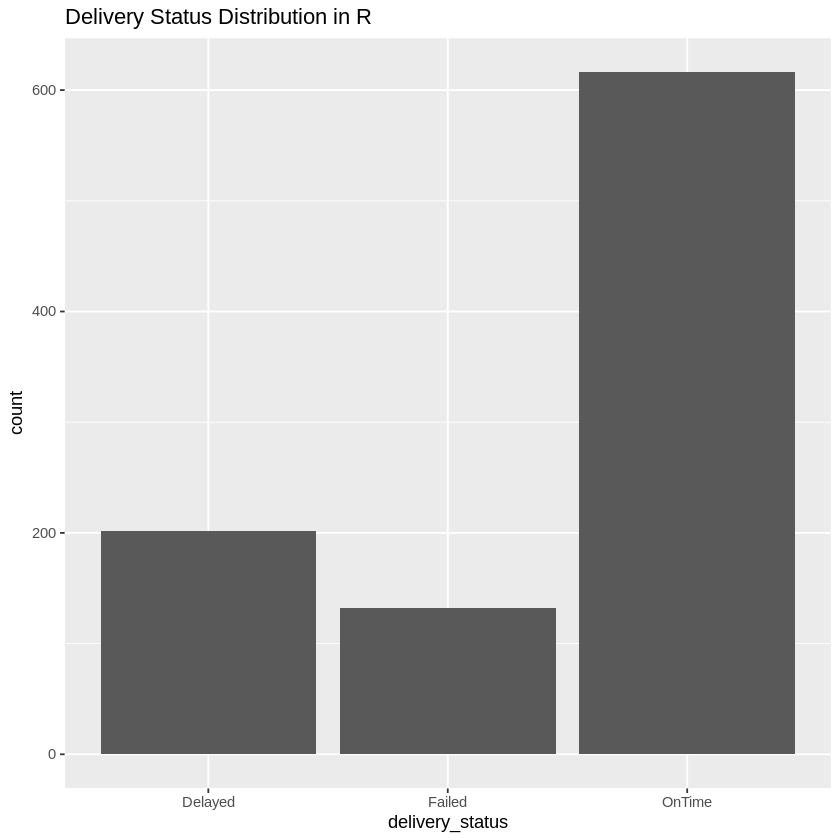

In [ ]:
ggplot(deliveries, aes(x=delivery_status)) +
geom_bar() +
ggtitle("Delivery Status Distribution in R")